# **Trabalho Detecção de Fraude — P2**

| ALUNAS | RA |
| :--- | ---: |
| Amanda Moura | 202327-8 |
| Isabella Duarte | 203110-7 |
| Sarah Costa | 204136-5 |

In [ ]:
#Quais bibliotecas foram utilizadas e suas respectivas funções

# Manipulação de dados e álgebra linear
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler

# Divisão e validação dos dados
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# Tratamento de desbalanceamento — SMOTE
from imblearn.over_sampling import SMOTE

# Salvamento do modelo
import joblib

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

print("Shape do dataset:", df.shape)

Shape do dataset: (286784, 31)


In [ ]:
print("Tipos de dados:")
print(df.dtypes)

Tipos de dados:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object


In [ ]:
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,...,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286783.000000,286783.000000,286783.000000,286783.000000
mean,95113.111237,0.001817,-0.001189,-0.005255,-0.001459,0.002155,-0.000095,0.001111,-0.000792,-0.000345,...,0.000461,0.001010,0.000163,-0.000271,-0.000220,-0.000217,-0.000154,-0.000062,88.472746,0.001716
std,47460.289792,1.959368,1.652558,1.516311,1.416460,1.380385,1.332857,1.237193,1.195545,1.098390,...,0.735284,0.726498,0.624694,0.605811,0.624712,0.482114,0.404041,0.330281,250.342306,0.041384
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54409.000000,-0.919402,-0.599550,-0.897729,-0.850159,-0.689698,-0.768846,-0.553660,-0.209194,-0.643246,...,-0.228329,-0.542180,-0.161797,-0.355073,-0.318019,-0.326989,-0.070950,-0.053138,5.600000,0.000000
50%,85319.000000,0.018928,0.064524,0.174412,-0.021456,-0.052484,-0.274695,0.041102,0.021756,-0.051055,...,-0.029006,0.007806,-0.010994,0.040736,0.015052,-0.052320,0.001209,0.011074,22.000000,0.000000
75%,139114.000000,1.317891,0.803310,1.023480,0.741110,0.614516,0.398476,0.571678,0.326786,0.596790,...,0.187254,0.530997,0.148085,0.439861,0.350281,0.240705,0.091012,0.078244,77.385000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,184.000000,3.517346,31.612198,33.847808,25691.160000,1.000000


In [ ]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
print("Distribuição da variável 'Class':")
print(df['Class'].value_counts())

print("\nDistribuição proporcional:")
print(df['Class'].value_counts(normalize=True))

Distribuição da variável 'Class':
Class
0.0    286291
1.0       492
Name: count, dtype: int64

Distribuição proporcional:
Class
0.0    0.998284
1.0    0.001716
Name: proportion, dtype: float64


## 3. Análise Exploratória de Dados (EDA)

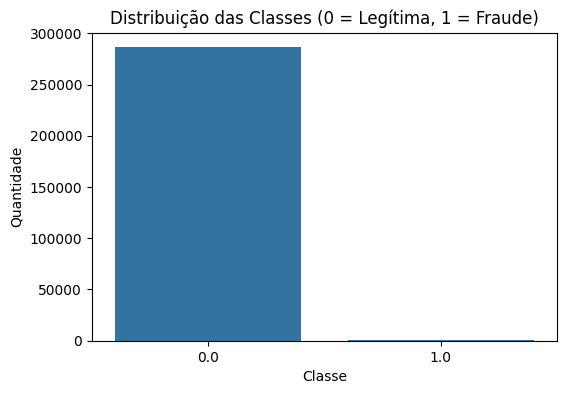

In [ ]:
# 3.1 Distribuição das classes — visualiza o desbalanceamento extremo (~0,17% fraude)
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribuição das Classes (0 = Legítima, 1 = Fraude)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

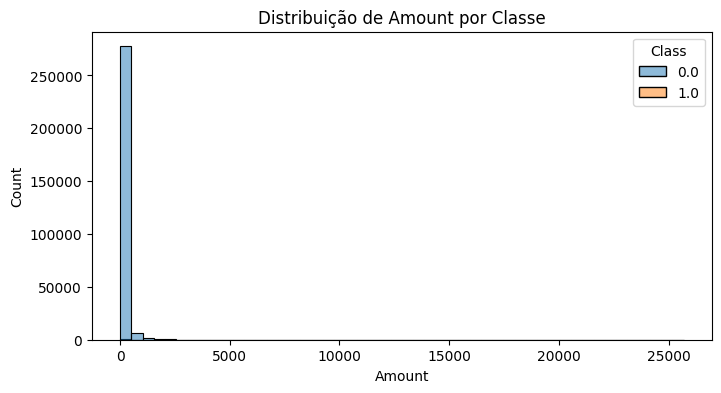

In [ ]:
# 3.2 Distribuição de Amount por classe
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Amount', hue='Class', bins=50, kde=False)
plt.title('Distribuição de Amount por Classe')
plt.show()

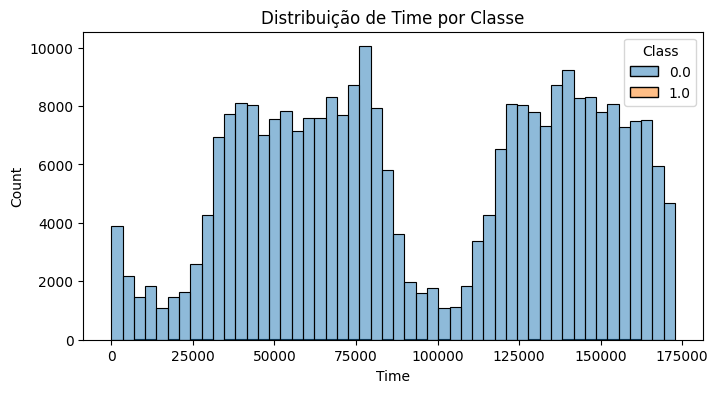

In [ ]:
# 3.3 Distribuição de Time por classe
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Time', hue='Class', bins=50, kde=False)
plt.title('Distribuição de Time por Classe')
plt.show()

In [ ]:
# 3.4 Estatísticas descritivas das features V1–V28
v_cols = [f'V{i}' for i in range(1, 29)]
display(df[v_cols].describe())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
count,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,...,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286784.000000,286783.000000,286783.000000
mean,0.001817,-0.001189,-0.005255,-0.001459,0.002155,-0.000095,0.001111,-0.000792,-0.000345,0.000660,...,0.000112,-0.000266,0.000461,0.001010,0.000163,-0.000271,-0.000220,-0.000217,-0.000154,-0.000062
std,1.959368,1.652558,1.516311,1.416460,1.380385,1.332857,1.237193,1.195545,1.098390,1.088849,...,0.814065,0.771700,0.735284,0.726498,0.624694,0.605811,0.624712,0.482114,0.404041,0.330281
min,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,...,-7.213527,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084
25%,-0.919402,-0.599550,-0.897729,-0.850159,-0.689698,-0.768846,-0.553660,-0.209194,-0.643246,-0.535353,...,-0.455960,-0.212026,-0.228329,-0.542180,-0.161797,-0.355073,-0.318019,-0.326989,-0.070950,-0.053138
50%,0.018928,0.064524,0.174412,-0.021456,-0.052484,-0.274695,0.041102,0.021756,-0.051055,-0.092191,...,0.004170,-0.062772,-0.029006,0.007806,-0.010994,0.040736,0.015052,-0.052320,0.001209,0.011074
75%,1.317891,0.803310,1.023480,0.741110,0.614516,0.398476,0.571678,0.326786,0.596790,0.454659,...,0.458756,0.132833,0.187254,0.530997,0.148085,0.439861,0.350281,0.240705,0.091012,0.078244
max,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,...,5.591971,39.420904,27.202839,10.503090,22.528412,4.584549,184.000000,3.517346,31.612198,33.847808


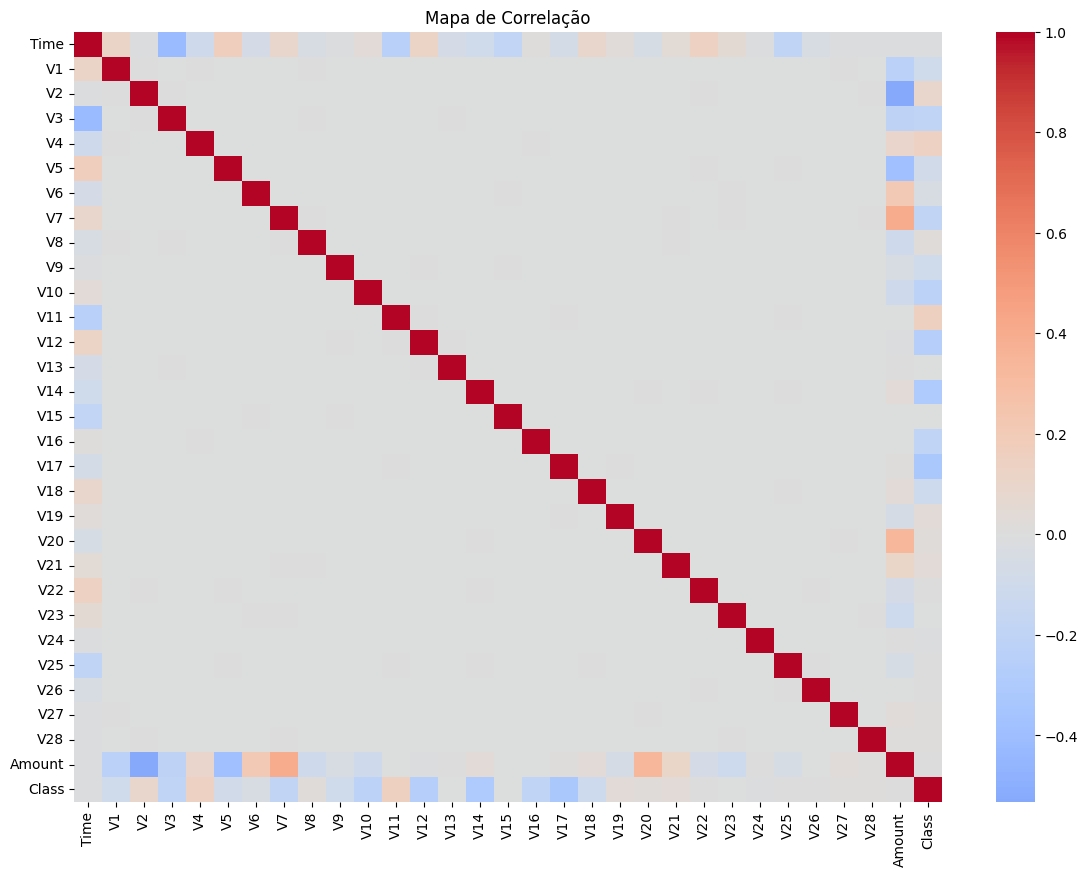

In [ ]:
# 3.5 Mapa de correlação entre as features
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Mapa de Correlação')
plt.show()

## 4. Pré-processamento

In [ ]:
# 4.1 Transformação logarítmica em Amount
df['Amount_log'] = np.log(df['Amount'] + 1)

In [ ]:
# 4.2 Padronização de Amount_log com StandardScaler
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount_log']])

In [ ]:
# 4.3 Remoção das colunas originais que não serão usadas
df = df.drop(['Time', 'Amount', 'Amount_log'], axis=1)

In [ ]:
# 4.4 Separação entre variáveis de entrada (X) e variável-alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
# Remoção de valores nulos
clean_indices = y.dropna().index
X = X.loc[clean_indices]
y = y.loc[clean_indices]

# 4.5 Divisão estratificada: 60% treino / 20% validação / 20% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print(f"Treino:    {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste:     {X_test.shape[0]} amostras")

Treino:    172069 amostras
Validação: 57357 amostras
Teste:     57357 amostras


####4.6 Tratamento do Desbalanceamento com SMOTE

In [ ]:
# Aplicação do SMOTE somente no conjunto de treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribuição ANTES do SMOTE:")
print(y_train.value_counts())

print("\nDistribuição APÓS o SMOTE:")
print(pd.Series(y_train_res).value_counts())

Distribuição ANTES do SMOTE:
Class
0.0    171774
1.0       295
Name: count, dtype: int64

Distribuição APÓS o SMOTE:
Class
0.0    171774
1.0    171774
Name: count, dtype: int64


##5. Treinamento dos Modelos

Modelo 1 — Regressão Logística

In [ ]:
model1 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model1.fit(X_train_res, y_train_res)

y_pred1 = model1.predict(X_test)
y_prob1 = model1.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred1, target_names=['Legítima', 'Fraude']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Legítima       1.00      0.97      0.99     57259
      Fraude       0.05      0.90      0.10        98

    accuracy                           0.97     57357
   macro avg       0.53      0.94      0.54     57357
weighted avg       1.00      0.97      0.98     57357



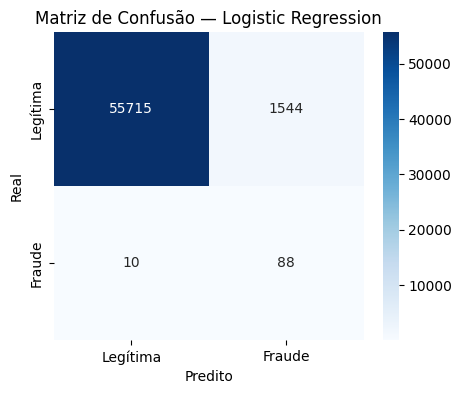

In [ ]:
# Matriz de Confusão — Regressão Logística
cm1 = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão — Logistic Regression')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Modelo 2 — Random Forest

In [ ]:
model2 = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
model2.fit(X_train_res, y_train_res)

y_pred2 = model2.predict(X_test)
y_prob2 = model2.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred2, target_names=['Legítima', 'Fraude']))

=== Random Forest ===
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     57259
      Fraude       0.93      0.79      0.85        98

    accuracy                           1.00     57357
   macro avg       0.96      0.89      0.93     57357
weighted avg       1.00      1.00      1.00     57357



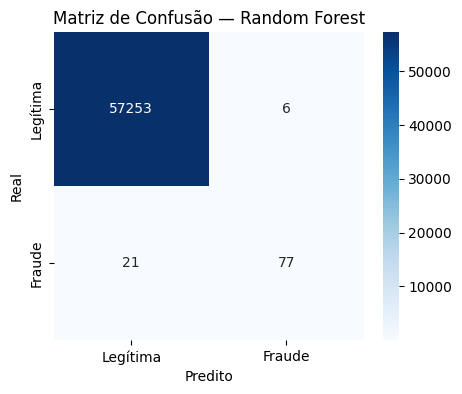

In [ ]:
# Matriz de Confusão — Random Forest
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão — Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Modelo 3 — AdaBoost (com SMOTE)

In [ ]:
model3 = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
model3.fit(X_train_res, y_train_res)

y_pred3 = model3.predict(X_test)
y_prob3 = model3.predict_proba(X_test)[:, 1]

print("=== AdaBoost ===")
print(classification_report(y_test, y_pred3, target_names=['Legítima', 'Fraude']))

=== AdaBoost ===
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99     57259
      Fraude       0.06      0.91      0.11        98

    accuracy                           0.98     57357
   macro avg       0.53      0.94      0.55     57357
weighted avg       1.00      0.98      0.99     57357



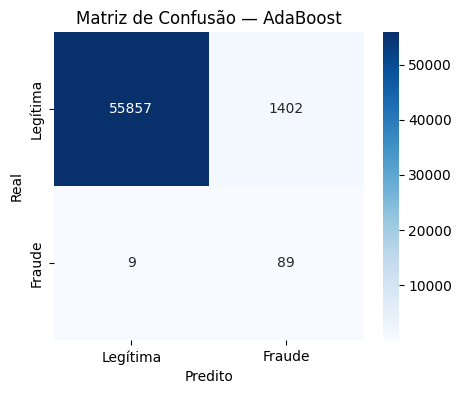

In [ ]:
# Matriz de Confusão — AdaBoost
cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão — AdaBoost')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

##6. Validação Cruzada (Stratified K-Fold, k=5)

In [ ]:
# StratifiedKFold garante que cada fold mantenha a proporção de classes
# Usamos AUC-PR como métrica (mais informativa que AUC-ROC para dados desbalanceados)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
}

print("=== VALIDAÇÃO CRUZADA (AUC-PR) — treino com SMOTE ===")
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_res,   # dados balanceados pelo SMOTE
        y_train_res,
        cv=skf,
        scoring='average_precision'
    )
    print(f"\n{name}")
    print("  Scores por fold:", np.round(scores, 4))
    print(f"  Média AUC-PR: {scores.mean():.4f} ± {scores.std():.4f}")

=== VALIDAÇÃO CRUZADA (AUC-PR) — treino com SMOTE ===

Logistic Regression
  Scores por fold: [0.9921 0.9924 0.9922 0.9921 0.992 ]
  Média AUC-PR: 0.9922 ± 0.0001

Random Forest
  Scores por fold: [1. 1. 1. 1. 1.]
  Média AUC-PR: 1.0000 ± 0.0000

AdaBoost
  Scores por fold: [0.9959 0.9962 0.9962 0.9963 0.9959]
  Média AUC-PR: 0.9961 ± 0.0002


##7. Curvas ROC Sobrepostas

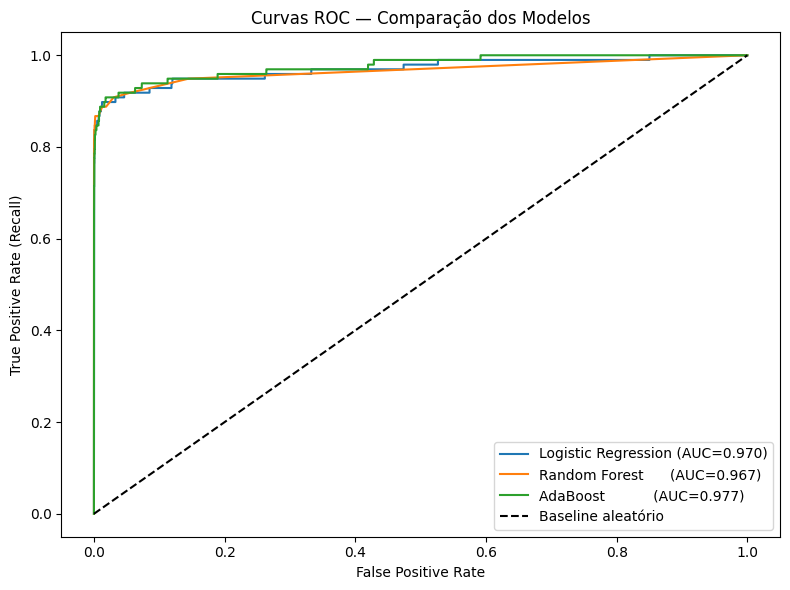

In [ ]:
fpr1, tpr1, _ = roc_curve(y_test, y_prob1)
fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
fpr3, tpr3, _ = roc_curve(y_test, y_prob3)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC={auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'Random Forest      (AUC={auc2:.3f})')
plt.plot(fpr3, tpr3, label=f'AdaBoost           (AUC={auc3:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline aleatório')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curvas ROC — Comparação dos Modelos')
plt.legend()
plt.tight_layout()
plt.show()

##8. Ajuste de Threshold com o Conjunto de Validação

In [ ]:
val_probs = {
    "Logistic Regression": model1.predict_proba(X_val)[:, 1],
    "Random Forest":       model2.predict_proba(X_val)[:, 1],
    "AdaBoost":            model3.predict_proba(X_val)[:, 1]
}

best_thresholds = {}

for name, probs in val_probs.items():
    precisions, recalls, thresholds = precision_recall_curve(y_val, probs)
    # F1 por threshold
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_thresholds[name] = best_thresh
    print(f"{name}: melhor threshold = {best_thresh:.3f}  →  F1 na validação = {f1_scores[best_idx]:.4f}")

Logistic Regression: melhor threshold = 1.000  →  F1 na validação = 0.8128
Random Forest: melhor threshold = 0.430  →  F1 na validação = 0.8437
AdaBoost: melhor threshold = 0.616  →  F1 na validação = 0.7650


In [ ]:
# Aplicação dos thresholds otimizados no conjunto de TESTE
print("=== Resultados com threshold otimizado (conjunto de teste) ===")

test_probs  = [y_prob1, y_prob2, y_prob3]
model_names = ["Logistic Regression", "Random Forest", "AdaBoost"]

for name, probs in zip(model_names, test_probs):
    thresh = best_thresholds[name]
    y_pred_thresh = (probs >= thresh).astype(int)
    print(f"\n{name} (threshold={thresh:.3f})")
    print(classification_report(y_test, y_pred_thresh, target_names=['Legítima', 'Fraude']))

=== Resultados com threshold otimizado (conjunto de teste) ===

Logistic Regression (threshold=1.000)
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     57259
      Fraude       0.81      0.77      0.79        98

    accuracy                           1.00     57357
   macro avg       0.90      0.88      0.89     57357
weighted avg       1.00      1.00      1.00     57357


Random Forest (threshold=0.430)
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     57259
      Fraude       0.89      0.82      0.85        98

    accuracy                           1.00     57357
   macro avg       0.94      0.91      0.93     57357
weighted avg       1.00      1.00      1.00     57357


AdaBoost (threshold=0.616)
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     57259
      Fraude       0.83      0.69      0.76        98

    accuracy       

##9. Tabela Comparativa de Métricas

In [ ]:
resultados = []

for name, y_pred, y_prob in [
    ("Logistic Regression", y_pred1, y_prob1),
    ("Random Forest",       y_pred2, y_prob2),
    ("AdaBoost",            y_pred3, y_prob3)
]:
    resultados.append({
        "Classificador": name,
        "Acurácia":  round(accuracy_score(y_test, y_pred), 4),
        "Precisão":  round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4),
        "AUC-ROC":   round(roc_auc_score(y_test, y_prob), 4),
        "AUC-PR":    round(average_precision_score(y_test, y_prob), 4)
    })

df_tabela = pd.DataFrame(resultados).set_index('Classificador')
display(df_tabela)

,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,AUC-PR
Classificador,,,,,,
Logistic Regression,0.9729,0.0539,0.8980,0.1017,0.9703,0.6850
Random Forest,0.9995,0.9277,0.7857,0.8508,0.9665,0.8370
AdaBoost,0.9754,0.0597,0.9082,0.1120,0.9769,0.7485


##10. Importância das Features — Random Forest

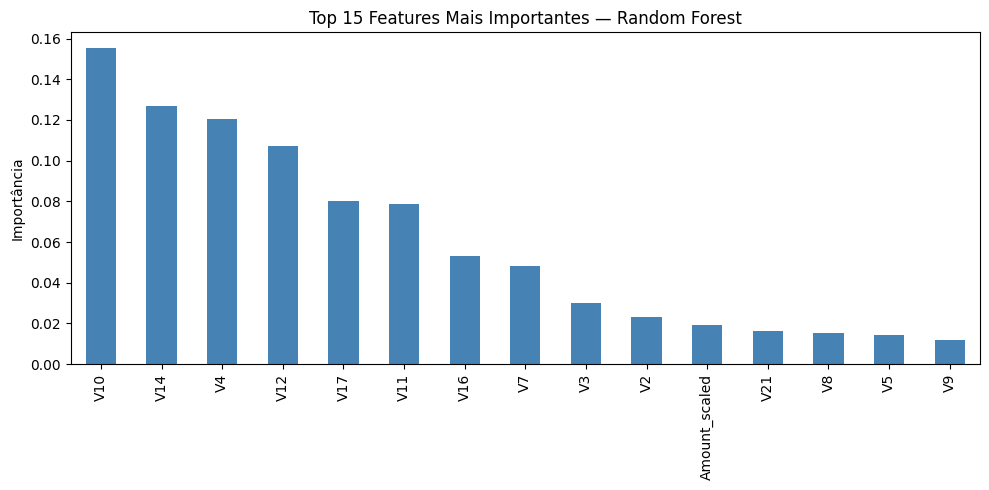

In [ ]:
importances = model2.feature_importances_
feat_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_series.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Features Mais Importantes — Random Forest')
plt.ylabel('Importância')
plt.tight_layout()
plt.show()

##12. Salvamento do Modelo Final
(etapa importante. O salvamento é necessário porque o app Streamlit é um programa separado do notebook; ele não tem acesso ao modelo que está na memória do Colab, só ao arquivo)

In [ ]:
joblib.dump(model2, 'modelo_final.joblib')
print("Modelo salvo em: modelo_final.joblib")

# Salvamento do scaler para uso no app (necessário para transformar Amount antes de predizer)
joblib.dump(scaler, 'scaler.joblib')
print("Scaler salvo em: scaler.joblib")

Modelo salvo em: modelo_final.joblib
Scaler salvo em: scaler.joblib


In [ ]:
# Verificação: carregamento do modelo e predição de teste
modelo_carregado = joblib.load('modelo_final.joblib')
y_check = modelo_carregado.predict(X_test[:5])
print("Predições de verificação:", y_check)

Predições de verificação: [0. 0. 0. 0. 0.]
